In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy import stats

Load Data

In [2]:
# Get root directory and data directory
PROJECT_ROOT = Path.cwd().resolve().parents[0]
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "Processed" / "retailhero_causal_forest_features.csv"

# Load data
processed_df = pd.read_csv(PROCESSED_DATA_PATH)
print(processed_df.head())

    client_id  age  gender_F  gender_M  gender_U  num_transactions  \
0  000012768d   45         0         0         1                 4   
1  000036f903   72         1         0         0                32   
2  00010925a5   83         0         0         1                18   
3  0001f552b0   33         1         0         0                15   
4  00020e7b18   73         0         0         1                18   

   num_unique_products  num_stores_visited  total_quantity  \
0                   46                   3            54.0   
1                   96                   5           169.0   
2                   58                   2            79.0   
3                   79                   4           106.0   
4                  175                   4           394.0   

   avg_items_per_transaction  ...  regular_points_spent  \
0                  13.500000  ...                   0.0   
1                   5.281250  ...                   0.0   
2                   4.388889 

## ATE Benchmark 1: Unweighted (Difference-in-Means)

Function: compute_ate_benchmark

In [3]:
def compute_ate_benchmark(features: pd.DataFrame,
                          treatment_col: str = "treatment",
                          target_col: str = "target") -> dict:

    # Filter out treated and untreated columns
    treated = features.loc[features["treatment"] == 1, target_col]
    control = features.loc[features["treatment"] == 0, target_col]

    # Find the mean of (Y | T=1) and (Y | T=0)
    mean_treated = treated.mean()
    mean_control = control.mean()

    # Find ATE for entire population
    ate_hat = mean_treated - mean_control

    return {
        "n_treated": len(treated),
        "n_control": len(control),
        "mean_treated": mean_treated,
        "mean_control": mean_control,
        "ATE_benchmark": ate_hat
    }

Run benchmark and show results

In [4]:
print("=" * 60)
print("ATE Benchmark (simple difference in means)")
print("=" * 60)
results = compute_ate_benchmark(processed_df)
print(f"n_treated = {results['n_treated']}")
print(f"n_control = {results['n_control']}")
print(f"P(purchase | treated) = {results['mean_treated']:.4f}")
print(f"P(purchase | control) = {results['mean_control']:.4f}")
print(f"\nBenchmark ATE estimate = {results['ATE_benchmark']:.4f}")

ATE Benchmark (simple difference in means)
n_treated = 99981
n_control = 100058
P(purchase | treated) = 0.6365
P(purchase | control) = 0.6033

Benchmark ATE estimate = 0.0332


Testing significance of ATE

In [5]:
# Welch's t-test because we don't assume equal variance across both groups
t_result = stats.ttest_ind(
    processed_df.loc[processed_df["treatment"] == 1, "target"],
    processed_df.loc[processed_df["treatment"] == 0, "target"],
    equal_var=False,    
)
ci_low, ci_high = t_result.confidence_interval(confidence_level=0.95)

ate = (
    processed_df.loc[processed_df["treatment"] == 1, "target"].mean()
    - processed_df.loc[processed_df["treatment"] == 0, "target"].mean()
)

se_ate = ate / t_result.statistic

print(f"ATE            = {ate:.4f}")
print(f"Standard error = {se_ate:.4f}")
print(f"t-statistic    = {t_result.statistic:.3f}")
print(f"p-value        = {t_result.pvalue:.4g}")
print(f"95% CI for ATE = [{ci_low:.4f}, {ci_high:.4f}]")

ATE            = 0.0332
Standard error = 0.0022
t-statistic    = 15.318
p-value        = 6.181e-53
95% CI for ATE = [0.0290, 0.0375]


## ATE Benchmark 2: Density-Weighted (From X5 Paper)

Paper Default Parameters

In [6]:
N_LATENT_DIMS = 2   # Latent dimensionality used in the paper
N_GRID = 20    # 20x20 bins used in paper
MIN_BIN_COUNT = 1     # At least one of each (treated and control) per bin

Load features

In [7]:
covariate_cols = [
    c for c in processed_df.columns
    if c not in ("client_id", "treatment", "target")
]

print(f"Rows: {len(processed_df)}")
print(f"Covariates used for dimensionality reduction ({len(covariate_cols)}):")
print(covariate_cols)

processed_df.isna().sum()[processed_df.isna().sum() > 0]   # check for NaN values

Rows: 200039
Covariates used for dimensionality reduction (22):
['age', 'gender_F', 'gender_M', 'gender_U', 'num_transactions', 'num_unique_products', 'num_stores_visited', 'total_quantity', 'avg_items_per_transaction', 'total_spend', 'avg_transaction_spend', 'median_transaction_spend', 'spend_std', 'regular_points_received', 'regular_points_spent', 'express_points_received', 'express_points_spent', 'net_regular_points_change', 'net_express_points_change', 'days_since_last_purchase', 'avg_days_between_transactions', 'customer_activity_span']


Series([], dtype: int64)

Step 1: Dimensionality Reduction (to 2D)

In [8]:
z_scores = np.abs(stats.zscore(processed_df[covariate_cols]))
outlier_mask = (z_scores > 5).any(axis=1)  # rows with any covariate >5 SDs from mean
print(f"Outliers: {outlier_mask.sum()} ({100*outlier_mask.mean():.2f}%)")

features_clean = processed_df[~outlier_mask].reset_index(drop=True)

Outliers: 9095 (4.55%)


In [9]:
def signed_log1p(x: np.ndarray) -> np.ndarray:
    return np.sign(x) * np.log1p(np.abs(x))

def reduce_to_latent_space(features: pd.DataFrame, covariate_cols: list[str],
                            n_components: int = N_LATENT_DIMS) -> np.ndarray:
    X = features[covariate_cols].to_numpy()
    X_log = signed_log1p(X)  
    X_scaled = StandardScaler().fit_transform(X_log)
    latent = PCA(n_components=n_components, random_state=0).fit_transform(X_scaled)
    return latent


latent = reduce_to_latent_space(processed_df, covariate_cols)
latent.shape

(200039, 2)

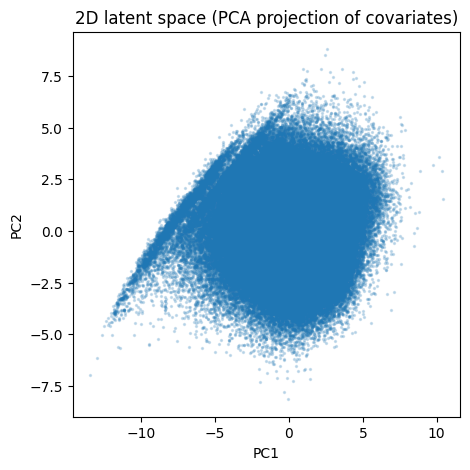

In [10]:
# To visualise the data points in a 2D space
plt.figure(figsize=(5, 5))
plt.scatter(latent[:, 0], latent[:, 1], s=2, alpha=0.2)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D latent space (PCA projection of covariates)")
plt.show()

Step 2: Grid the latent space into 20x20

In [11]:
def assign_grid_bins(latent: np.ndarray, n_grid: int = N_GRID) -> np.ndarray:
    n_dims = latent.shape[1]
    bin_indices_per_dim = []

    for d in range(n_dims):
        edges = np.linspace(latent[:, d].min(), latent[:, d].max(), n_grid + 1)
        # np.digitize with inner edges only, so indices run 0..n_grid-1
        idx = np.digitize(latent[:, d], edges[1:-1])
        bin_indices_per_dim.append(idx)

    # Flatten multi-dimensional bin coordinates into a single integer bin id
    bin_id = np.zeros(len(latent), dtype=int)
    for d, idx in enumerate(bin_indices_per_dim):
        bin_id = bin_id * n_grid + idx

    return bin_id


features_binned = processed_df.copy()
features_binned["bin"] = assign_grid_bins(latent, n_grid=N_GRID)
features_binned[["bin"]].describe()

,bin
count,200039.000000
mean,224.536835
std,42.848435
min,1.000000
25%,205.000000
50%,228.000000
75%,250.000000
max,393.000000


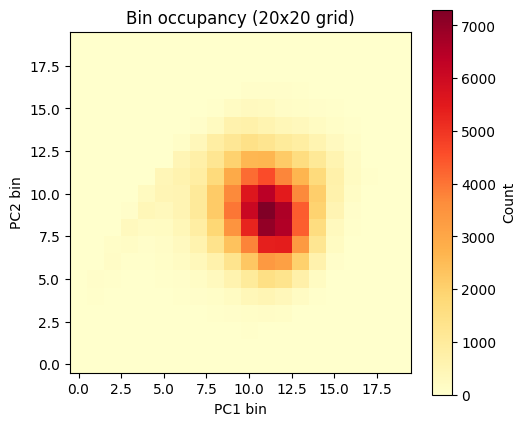

In [12]:
# Visualize bin occupancy 
bin_2d = assign_grid_bins(latent, n_grid=N_GRID)
x_idx = np.digitize(latent[:, 0], np.linspace(latent[:, 0].min(), latent[:, 0].max(), N_GRID + 1)[1:-1])
y_idx = np.digitize(latent[:, 1], np.linspace(latent[:, 1].min(), latent[:, 1].max(), N_GRID + 1)[1:-1])

density_grid = np.zeros((N_GRID, N_GRID))
for xi, yi in zip(x_idx, y_idx):
    density_grid[yi, xi] += 1

plt.figure(figsize=(5.5, 5))
plt.imshow(density_grid, origin="lower", cmap="YlOrRd")
plt.colorbar(label="Count")
plt.title(f"Bin occupancy ({N_GRID}x{N_GRID} grid)")
plt.xlabel("PC1 bin")
plt.ylabel("PC2 bin")
plt.show()

Step 3: Density-Weighted ATE

In [13]:
def compute_ate_density_weighted(
    features: pd.DataFrame,
    covariate_cols: list[str],
    treatment_col: str = "treatment",
    target_col: str = "target",
    n_components: int = N_LATENT_DIMS,
    n_grid: int = N_GRID,
    min_bin_count: int = MIN_BIN_COUNT,
) -> dict:
    df = features.copy()

    latent = reduce_to_latent_space(df, covariate_cols, n_components=n_components)
    df["bin"] = assign_grid_bins(latent, n_grid=n_grid)

    n_total = len(df)
    total_bins_possible = n_grid ** n_components

    ate_terms = []
    bin_records = []
    n_bins_dropped = 0
    n_dropped_rows = 0

    for b, group in df.groupby("bin"):
        treated_y = group.loc[group[treatment_col] == 1, target_col]
        control_y = group.loc[group[treatment_col] == 0, target_col]

        if len(treated_y) < min_bin_count or len(control_y) < min_bin_count:
            n_bins_dropped += 1
            n_dropped_rows += len(group)
            continue

        p_b = len(group) / n_total
        local_uplift = treated_y.mean() - control_y.mean()
        contribution = p_b * local_uplift

        ate_terms.append(contribution)
        bin_records.append({
            "bin": b,
            "n_total": len(group),
            "n_treated": len(treated_y),
            "n_control": len(control_y),
            "p_b": p_b,
            "local_uplift": local_uplift,
            "contribution": contribution,
        })

    ate_hat = sum(ate_terms)

    return {
        "ate_hat": ate_hat,
        "n_bins_used": len(bin_records),
        "n_bins_possible": total_bins_possible,
        "n_bins_dropped": n_bins_dropped,
        "n_rows_dropped": n_dropped_rows,
        "pct_rows_dropped": 100 * n_dropped_rows / n_total,
        "bin_details": pd.DataFrame(bin_records),
    }


results = compute_ate_density_weighted(processed_df, covariate_cols)

print(f"Bins used: {results['n_bins_used']} / {results['n_bins_possible']} possible")
print(f"Bins dropped (too sparse): {results['n_bins_dropped']}")
print(f"Rows dropped: {results['n_rows_dropped']} ({results['pct_rows_dropped']:.2f}% of population)")
print(f"\nEq. (16) ATE estimate = {results['ate_hat']:.4f}")

Bins used: 209 / 400 possible
Bins dropped (too sparse): 30
Rows dropped: 42 (0.02% of population)

Eq. (16) ATE estimate = 0.0320


Bootstrap and testing its significance

In [14]:
def bootstrap_ate_ci(estimator_fn, features: pd.DataFrame, n_boot: int = 500,
                      alpha: float = 0.05, random_state: int = 0, **kwargs) -> dict:
    rng = np.random.default_rng(random_state)
    n = len(features)
    boot_ates = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)              # resample rows with replacement
        sample = features.iloc[idx].reset_index(drop=True)
        result = estimator_fn(sample, **kwargs)
        boot_ates.append(result.get("ate_hat", result.get("ATE_benchmark")))

    boot_ates = np.array(boot_ates)
    se = boot_ates.std(ddof=1)
    lo, hi = np.percentile(boot_ates, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    p_value = 2 * min((boot_ates > 0).mean(), (boot_ates < 0).mean())

    return {"se": se, "ci": (lo, hi), "p_value": p_value, "boot_ates": boot_ates}


boot_results = bootstrap_ate_ci(
    compute_ate_density_weighted, processed_df,
    covariate_cols=covariate_cols, n_boot=500,
)
print(f"Bootstrap SE      = {boot_results['se']:.4f}")
print(f"95% CI for ATE    = [{boot_results['ci'][0]:.4f}, {boot_results['ci'][1]:.4f}]")
print(f"Bootstrap p-value = {boot_results['p_value']:.4g}")

Bootstrap SE      = 0.0020
95% CI for ATE    = [0.0278, 0.0358]
Bootstrap p-value = 0


Inspect contributions per bin

In [15]:
bin_details = results["bin_details"].sort_values("contribution", ascending=False)
bin_details.head(10)

,bin,n_total,n_treated,n_control,p_b,local_uplift,contribution
115,229,7298,3595,3703,0.036483,0.046001,0.001678
132,249,6605,3366,3239,0.033019,0.033150,0.001095
113,227,5381,2721,2660,0.026900,0.040372,0.001086
99,210,5606,2782,2824,0.028025,0.037669,0.001056
98,209,6095,3033,3062,0.030469,0.033181,0.001011
66,168,1825,900,925,0.009123,0.110781,0.001011
100,211,4127,2129,1998,0.020631,0.045749,0.000944
114,228,6995,3562,3433,0.034968,0.026963,0.000943
95,206,2251,1104,1147,0.011253,0.079317,0.000893
117,231,4598,2266,2332,0.022986,0.037777,0.000868


Paper reports minimal dependence on the grid resolution, so perform checks by replicating 10x10 and 30x30 grids.

In [16]:
for n_grid in [10, 20, 30]:
    r = compute_ate_density_weighted(processed_df, covariate_cols, n_grid=n_grid)
    print(f"n_grid={n_grid:>2} -> ATE = {r['ate_hat']:.4f}  "
          f"(bins used: {r['n_bins_used']}/{r['n_bins_possible']}, "
          f"rows dropped: {r['pct_rows_dropped']:.2f}%)")

n_grid=10 -> ATE = 0.0321  (bins used: 64/100, rows dropped: 0.00%)
n_grid=20 -> ATE = 0.0320  (bins used: 209/400, rows dropped: 0.02%)
n_grid=30 -> ATE = 0.0319  (bins used: 422/900, rows dropped: 0.04%)
